# SatQuery Walkthrough

This notebook is a hands-on tour of SatQuery's agentic remote-sensing backend:
what each of the 8 science tools (plus the vision tool) takes in and returns,
and — via five real, executed examples — how the LangGraph orchestrator
actually decides what to do, calls tools, and produces a grounded answer.

**Every code cell below was actually run against a live SatQuery backend**
(GPT-4o as the orchestrator, GPT-4o vision as the vision-tool backend) — the
outputs you see, including the raw `[STAGE]`-tagged log lines showing every
tool call's exact argument payload, the complete raw JSON each tool returned,
and rendered image previews of every input and output raster, are genuine,
not illustrative. Re-running the cells yourself will produce very similar
(not necessarily byte-identical) results, since GPT-4o's phrasing varies
between calls and Sentinel Hub's catalog changes over time.

## Prerequisites to re-run this yourself

- Run from the SatQuery project root, using the project's `.venv` interpreter
  as the notebook kernel (`.venv/bin/python`, or point Jupyter/VS Code at it).
- A configured `.env` with `SATQUERY_ORCHESTRATOR_PROVIDER=openai`,
  `SATQUERY_ORCHESTRATOR_MODEL=gpt-4o` (or similar), a valid `OPENAI_API_KEY`,
  `SATQUERY_VISION_TOOL_ENABLED=true`, `SATQUERY_VISION_TOOL_PROVIDER=openai`,
  and real `SENTINEL_CLIENT_ID`/`SENTINEL_CLIENT_SECRET` for the two examples
  that fetch live Sentinel-1 SAR data.
- This notebook calls the LangGraph orchestrator **directly in-process**
  (`backend.orchestrator.graph.invoke_satquery`) — no running HTTP server is
  needed, matching the pattern in `backend/demo.py`.
- If `jupyter`/`ipykernel` aren't already installed in `.venv`, add them
  (`pip install jupyterlab ipykernel`) to actually execute cells yourself;
  every cell already shows its real, previously-captured output either way.

## What "the agent" actually is

Every request runs through one bounded LangGraph state machine:

```
START -> validate -> plan -> (call_tool?) -> execute -> advance -> plan -> ...
                                                              \-> respond -> END
```

- **validate**: checks the query and any bbox/lat-lon are well-formed.
- **plan**: classifies intent (single tool vs. a named multi-step "mission"
  vs. a generic "chain"), then picks the next tool to call — via a
  deterministic keyword matcher (`SATQUERY_ORCHESTRATOR_PROVIDER=mock`) or a
  live LLM (`openai`/`anthropic`).
- **execute**: calls exactly one tool with backend-computed ("trusted")
  arguments — the LLM only ever picks *which* tool, never fabricates
  coordinates, dates, or file paths.
- **advance**: records what the tool produced, runs safety gates (e.g. don't
  run change-detection on two rasters that aren't grid-aligned), and decides
  whether more steps remain.
- **respond**: builds the final answer — either a templated string, or (as in
  every example below) a short narrative synthesized by the same LLM from the
  *actual* tool output.

Every stage below logs a `[TAG]` line as it happens — including a `[TOOL
CALL]` line with the **exact argument payload** sent to every tool — so you
can watch this loop unfold in real time in the raw output of each cell. Each
example also prints a `FULL TOOL CALL / RESPONSE PAYLOADS` block afterward
with the complete, unedited JSON every tool actually returned (not just the
final narrative answer), plus rendered previews of every raster involved.

In [1]:
import logging, sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/dhruvpandey/Desktop/satquery")
sys.path.insert(0, str(PROJECT_ROOT))

# Same log format backend/main.py configures for uvicorn — makes the
# [STAGE]-tagged lines from backend/orchestrator/nodes.py and
# backend/tools/executor.py visible right here in the notebook, including
# the exact argument payload sent to every tool call.
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s")

from backend.orchestrator.graph import invoke_satquery
from backend.orchestrator.state import empty_state
from backend.rendering.raster_preview import render_geotiff_preview
from IPython.display import Image, display

print("Setup complete. Project root:", PROJECT_ROOT)

Setup complete. Project root: /Users/dhruvpandey/Desktop/satquery


## Tool reference

Below is the *actual* input contract for each of the 8 science tools —
generated by introspecting their real Pydantic request models (not hand-typed
documentation that can drift from the code). "REQUIRED" fields have no
default and must be supplied; everything else falls back to the default shown
if the orchestrator's `trusted_args_for_tool()` doesn't have a better value
for it.

In [2]:
import sys
sys.path.insert(0, "/Users/dhruvpandey/Desktop/satquery")

from Tool_1_fetch_optical_imagery.fetch_optical_imagery import OpticalSatelliteRequest
from Tool_2_fetch_multispectral_imagery.fetch_multispectral_imagery import MultispectralSatelliteRequest
from Tool_3_fetch_sar_imagery.fetch_sar_imagery import SARSatelliteRequest
from Tool_4_fetch_weather_environment.fetch_weather_environment import WeatherEnvironmentRequest
from Tool_5_compute_vegetation_indices.compute_vegetation_indices import VegetationIndicesRequest
from Tool_6_inspect_geotiff_metadata.inspect_geotiff_metadata import GeoTIFFInspectionRequest
from Tool_7_analyze_temporal_change.analyze_temporal_change import TemporalChangeRequest
from Tool_8_analyze_spatial_landcover_terrain.analyze_spatial_landcover_terrain import SpatialLandcoverTerrainRequest

TOOLS = [
    ("Tool 1 — fetch_optical_imagery", OpticalSatelliteRequest, "Sentinel-2 true-color RGB GeoTIFF for a bbox + date range.", "Sentinel Hub API"),
    ("Tool 2 — fetch_multispectral_imagery", MultispectralSatelliteRequest, "Sentinel-2 multi-band surface reflectance GeoTIFF.", "Sentinel Hub API"),
    ("Tool 3 — fetch_sar_imagery", SARSatelliteRequest, "Sentinel-1 SAR/radar backscatter GeoTIFF.", "Sentinel Hub API"),
    ("Tool 4 — fetch_weather_environment", WeatherEnvironmentRequest, "ERA5/ERA5-Land weather + environmental context.", "Open-Meteo API (no key)"),
    ("Tool 5 — compute_vegetation_indices", VegetationIndicesRequest, "NDVI/EVI/SAVI/... from a multispectral GeoTIFF.", "Offline (numpy/rasterio)"),
    ("Tool 6 — inspect_geotiff_metadata", GeoTIFFInspectionRequest, "CRS/bounds/statistics/QA for any GeoTIFF.", "Offline (numpy/rasterio)"),
    ("Tool 7 — analyze_temporal_change", TemporalChangeRequest, "Before/after differencing + change mask.", "Offline (numpy/rasterio)"),
    ("Tool 8 — analyze_spatial_landcover_terrain", SpatialLandcoverTerrainRequest, "LULC composition, fragmentation, DEM slope, zonal cross-tab.", "Offline (numpy/rasterio/scipy)"),
]

for title, model, desc, dep in TOOLS:
    print(f"\n{'#' * 90}\n{title}\n{'#' * 90}")
    print(desc)
    print(f"Dependency: {dep}\n")
    print(f"{'field':<38}{'type':<22}{'required/default':<22}description")
    print("-" * 110)
    for name, field in model.model_fields.items():
        req = "REQUIRED" if field.is_required() else f"default={field.default!r}"
        type_str = str(field.annotation).replace("typing.", "")
        desc_str = field.description or ""
        print(f"{name:<38}{type_str:<22}{req:<22}{desc_str}")


##########################################################################################
Tool 1 — fetch_optical_imagery
##########################################################################################
Sentinel-2 true-color RGB GeoTIFF for a bbox + date range.
Dependency: Sentinel Hub API

field                                 type                  required/default      description
--------------------------------------------------------------------------------------------------------------
bbox                                  list[float]           REQUIRED              [min_lon, min_lat, max_lon, max_lat] in WGS84
start_date                            <class 'str'>         REQUIRED              YYYY-MM-DD
end_date                              <class 'str'>         REQUIRED              YYYY-MM-DD
max_cloud_cover                       <class 'float'>       default=30.0          
width                                 <class 'int'>         default=512           
height      

### The vision tool and the 3 mission pipelines (not plain Pydantic tools)

| | Input | Output | Dependency |
|---|---|---|---|
| **`analyze_imagery_vlm`** (vision tool) | `image_path` (GeoTIFF or PNG/JPEG) + `query` (natural-language question) | `{"text": "...", "model": "...", "provider": "..."}` — a natural-language answer | OpenAI vision API, or a local InternVL-1B/EarthMind-4B server, per `SATQUERY_VISION_TOOL_PROVIDER` |
| **`workflow_wildfire_burn_severity`** | `pre_raster_path`, `post_raster_path` (multispectral), `lulc_raster_path`, optional `dem_raster_path` | Burned-area stats, severity breakdown, zonal LULC/slope impact, generated NBR/difference/mask rasters | Offline — chains Tools 5 → 6 → 7 → 8 internally |
| **`workflow_flood_inundation_impact`** | `sar_pre_raster_path`, `sar_post_raster_path`, `lulc_raster_path`, optional weather + DEM | Inundated-area stats, flooded cropland/urban hectares, rainfall context | Offline — chains Tools 6 → 7 → (4) → 8 internally |
| **`workflow_agricultural_drought_canopy_stress`** | `multispectral_raster_path`, weather location | Drought risk tier, canopy vigor/moisture stats, soil/water balance | Offline — chains Tools 5 → 4 internally |

Unlike Tools 1–8, the vision tool is only called **on demand** (a query like
"describe this image") and is disabled by default
(`SATQUERY_VISION_TOOL_ENABLED=false`). The three missions aren't chosen by
name — they're triggered by intent keywords (`wildfire`, `flood`, `drought`)
classified *before* any single-tool keyword matching, and the orchestrator
builds their whole multi-step agenda up front (see `backend/orchestrator/
handshake.py`) rather than deciding one hop at a time.

---
## Example 1 — Visual Question Answering (VQA)

The simplest case: hand the agent an existing image and a plain-language
question about it. No location, no dates — just "what does this show?". The
orchestrator recognizes this needs the vision tool, renders the GeoTIFF to a
viewable PNG, and asks GPT-4o's vision API to answer. The `FULL TOOL CALL /
RESPONSE PAYLOADS` block shows the exact `{"text", "model", "provider"}` the
vision tool actually returned — the final narrative answer above it is
GPT-4o *re-phrasing* that same real text, not inventing anything new.

2026-09-08 23:19:08,452  INFO      satquery.pipeline  [REQUEST RECEIVED] query='What does this satellite image show? Describe the scene in detail.'
2026-09-08 23:19:08,453  INFO      satquery.pipeline  [IMAGE RECEIVED] input_file=/Users/dhruvpandey/Desktop/satquery/Tool_1_fetch_optical_imagery/test_runs/sample_optical_output.tif
2026-09-08 23:19:08,453  INFO      satquery.pipeline  [VALIDATION OK]
2026-09-08 23:19:08,454  INFO      satquery.pipeline  [ORCHESTRATOR INITIATED] provider=anthropic model=claude-sonnet-5
2026-09-08 23:19:11,940  INFO      httpx2  HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-09-08 23:19:11,958  INFO      satquery.pipeline  [ORCHESTRATOR TOOL CALL] tool=analyze_imagery_vlm reason="The user wants a visual description of the existing GeoTIFF's scene content, which is best handled by the VLM analysis tool rather than metadata inspection."
2026-09-08 23:19:11,959  INFO      satquery.pipeline  [TOOL CALL] analyze_imagery_vlm args=


STATUS: success
PLAN: {
  "action": "finish",
  "tool": null,
  "args": {},
  "reason": "The analyze_imagery_vlm result already provides a detailed visual description of the scene (urban area, road network, river with bridges, green spaces). Since the user only asked for a description of what the image shows, not identification of a specific real-world location, this is sufficient to answer confidently without further tool calls."
}

FINAL ANSWER:
 This satellite image shows a densely built urban area with an extensive network of roads and buildings. A major river runs vertically through the right side of the scene, crossed by several bridges, and there are visible patches of green space—likely parks or undeveloped land—interspersed among the development. Overall, the scene depicts a large city with the river as a key geographical feature shaping its layout.

##########################################################################################
FULL TOOL CALL / RESPONSE PAYLOADS
#

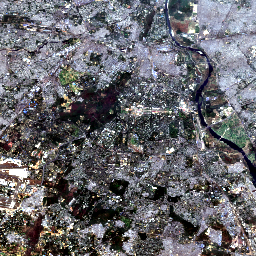

In [3]:
import logging, sys, json
from pathlib import Path
sys.path.insert(0, "/Users/dhruvpandey/Desktop/satquery")

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s")

from backend.orchestrator.graph import invoke_satquery
from backend.orchestrator.state import empty_state
from backend.rendering.raster_preview import render_geotiff_preview
from IPython.display import Image, display


def show_tool_results(result):
    print("\n" + "#" * 90)
    print("FULL TOOL CALL / RESPONSE PAYLOADS")
    print("#" * 90)
    for i, entry in enumerate(result.get("tool_results") or [], start=1):
        print(f"\n--- Step {i}: {entry['tool']}  (status={entry['result'].get('status')}, {entry.get('duration_ms', 0):.0f}ms) ---")
        print(json.dumps(entry["result"], indent=2, default=str))


image_path = str((Path("/Users/dhruvpandey/Desktop/satquery/Tool_1_fetch_optical_imagery/test_runs/sample_optical_output.tif")).resolve())

state = empty_state(
    query="What does this satellite image show? Describe the scene in detail.",
    input_file=image_path,
)
result = invoke_satquery(state)

print("\n" + "=" * 80)
print("STATUS:", result["status"])
print("PLAN:", json.dumps(result["plan"], indent=2))
print("\nFINAL ANSWER:\n", result["final_answer"])

show_tool_results(result)

print("\nInput image:")
display(Image(render_geotiff_preview(image_path, size=400)))

---
## Example 2 — Grounding: deriving a fetch location from an uploaded file

**The principle:** never ask the user for information the request already
contains in another form. Here we ask for a *different* sensor's imagery
(SAR) than the one we uploaded (optical) — and supply **no bbox and no
lat/lon anywhere**. `fetch_sar_imagery` needs a bounding box to know *where*
to fetch from Sentinel Hub... but the optical file we already uploaded is
itself georeferenced. Watch the log: the orchestrator runs
`inspect_geotiff_metadata` first (purely to read that file's own
`spatial.bounds_wgs84`), turns that into a `bbox`, and *then* calls
`fetch_sar_imagery` — a 2-hop chain, with no clarifying question asked and no
location invented. The cell output includes the **full metadata extracted**
from the uploaded file (CRS, resolution, exact bounds, per-band statistics
and histograms) and the **full raw response** `fetch_sar_imagery` returned
(scene ID, acquisition time, radar geometry quality, etc.) — not just the
one-line summary.

2026-09-08 23:19:20,169  INFO      satquery.pipeline  [REQUEST RECEIVED] query='Get me the SAR image for this area.'
2026-09-08 23:19:20,170  INFO      satquery.pipeline  [IMAGE RECEIVED] input_file=/Users/dhruvpandey/Desktop/satquery/Tool_1_fetch_optical_imagery/test_runs/sample_optical_output.tif
2026-09-08 23:19:20,171  INFO      satquery.pipeline  [VALIDATION OK]
2026-09-08 23:19:20,172  INFO      satquery.pipeline  [ORCHESTRATOR INITIATED] provider=anthropic model=claude-sonnet-5
2026-09-08 23:19:23,491  INFO      httpx2  HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-09-08 23:19:23,495  INFO      satquery.pipeline  [ORCHESTRATOR TOOL CALL] tool=inspect_geotiff_metadata reason="Deriving the fetch AOI from the uploaded file's own geospatial bounds."
2026-09-08 23:19:23,495  INFO      satquery.pipeline  [TOOL CALL] inspect_geotiff_metadata args={'file_path': '/Users/dhruvpandey/Desktop/satquery/Tool_1_fetch_optical_imagery/test_runs/sample_optical_ou


STATUS: success
TOOL CHAIN: ['inspect_geotiff_metadata -> success', 'fetch_sar_imagery -> success']

FINAL ANSWER:
 Your SAR image has been retrieved successfully. It's a Sentinel-1 radar scene (VV and VH polarization) covering the same area (77.1–77.3°E, 28.5–28.7°N), acquired on January 30, 2025 during an ascending orbit pass. The image quality is good, with no radar shadow interference and a favorable incidence angle (~40°), making it reliable for analysis even through clouds or at night.

METADATA EXTRACTED FROM THE UPLOADED FILE (spatial.bounds_wgs84 -> became step 2's bbox):
{
  "crs": "EPSG:4326",
  "is_geographic": true,
  "is_projected": false,
  "coordinate_units": "degrees",
  "resolution": {
    "x": 0.0007812500000000111,
    "y": 0.0007812499999999972,
    "unit": "degrees"
  },
  "bounds_native": {
    "left": 77.1,
    "bottom": 28.5,
    "right": 77.3,
    "top": 28.7
  },
  "bounds_wgs84": {
    "min_lon": 77.1,
    "min_lat": 28.5,
    "max_lon": 77.3,
    "max_lat"

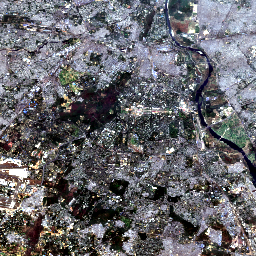

2026-09-08 23:19:38,788  WARNING   rasterio._env  CPLE_AppDefined in sentinel1_S1A_IW_GRDH_1SDV_20250130T125514_20250130T125543_057674_071BA5_E687_2025-01-01_2025-01-31_sar_20260908T174925Z.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
2026-09-08 23:19:38,789  WARNING   rasterio._env  CPLE_AppDefined in TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.



Output (SAR image fetched for the derived AOI):


/Users/dhruvpandey/Desktop/satquery/backend/rendering/raster_preview.py:54: RuntimeWarning: invalid value encountered in cast
  out = (scaled * 255.0).astype(np.uint8)


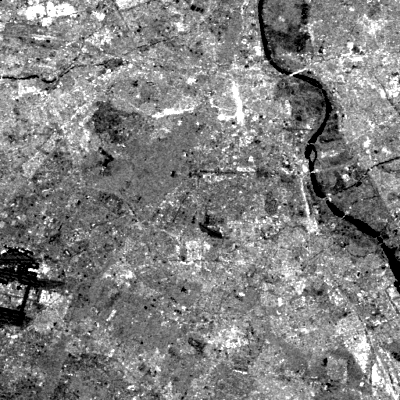

In [4]:
import logging, sys, json
from pathlib import Path
sys.path.insert(0, "/Users/dhruvpandey/Desktop/satquery")

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s")

from backend.orchestrator.graph import invoke_satquery
from backend.orchestrator.state import empty_state
from backend.rendering.raster_preview import render_geotiff_preview
from IPython.display import Image, display


def show_tool_results(result):
    print("\n" + "#" * 90)
    print("FULL TOOL CALL / RESPONSE PAYLOADS")
    print("#" * 90)
    for i, entry in enumerate(result.get("tool_results") or [], start=1):
        print(f"\n--- Step {i}: {entry['tool']}  (status={entry['result'].get('status')}, {entry.get('duration_ms', 0):.0f}ms) ---")
        print(json.dumps(entry["result"], indent=2, default=str))


image_path = str((Path("/Users/dhruvpandey/Desktop/satquery/Tool_1_fetch_optical_imagery/test_runs/sample_optical_output.tif")).resolve())

# Note: no bbox, no latitude/longitude anywhere in this request — only the
# uploaded optical file. fetch_sar_imagery needs a bbox; the orchestrator
# must derive one from the file's own geospatial bounds instead of asking.
state = empty_state(
    query="Get me the SAR image for this area.",
    input_file=image_path,
)
result = invoke_satquery(state)

print("\n" + "=" * 80)
print("STATUS:", result["status"])
print("TOOL CHAIN:", [f"{r['tool']} -> {r['result'].get('status')}" for r in result["tool_results"]])
print("\nFINAL ANSWER:\n", result["final_answer"])

# Step 1's raw result is the actual GeoTIFF metadata the orchestrator
# extracted -- this is where the derived bbox in step 2's args came from.
metadata_extracted = result["tool_results"][0]["result"]
print("\nMETADATA EXTRACTED FROM THE UPLOADED FILE (spatial.bounds_wgs84 -> became step 2's bbox):")
print(json.dumps(metadata_extracted.get("spatial"), indent=2))

show_tool_results(result)

sar_output_path = result["tool_results"][1]["result"]["data"]["file_path"]
print("\nInput (uploaded optical file):")
display(Image(render_geotiff_preview(image_path, size=400)))
print("\nOutput (SAR image fetched for the derived AOI):")
display(Image(render_geotiff_preview(sar_output_path, size=400)))

---
## Example 3 — Multi-modal VQA: fusing vision-language interpretation with independently retrieved data

A single visual description is one modality. Here we ground an answer about
one place in **two independent modalities**: a vision-language interpretation
of a SAR (radar) raster — a fundamentally different imaging physics than a
normal photo, all grayscale backscatter intensity, no color — and separately
retrieved ERA5 weather/environmental data for the same area. Each call is
grounded only in its own tool's real output (the cell prints both full raw
payloads — the vision tool's `{"text",...}` response and the weather tool's
complete metrics + daily time series); combining them (the closing note) is
what a downstream consumer — human or another agent — would do to get a
fuller picture than either modality gives alone.

2026-09-08 23:19:38,835  INFO      satquery.pipeline  [REQUEST RECEIVED] query='Describe what this radar image shows.'
2026-09-08 23:19:38,836  INFO      satquery.pipeline  [IMAGE RECEIVED] input_file=/Users/dhruvpandey/Desktop/satquery/Tool_3_fetch_sar_imagery/test_runs/sample_sar_output.tif
2026-09-08 23:19:38,836  INFO      satquery.pipeline  [VALIDATION OK]
2026-09-08 23:19:38,838  INFO      satquery.pipeline  [ORCHESTRATOR INITIATED] provider=anthropic model=claude-sonnet-5


### Modality A: vision-language interpretation of a SAR (radar) raster ###



2026-09-08 23:19:41,847  INFO      httpx2  HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-09-08 23:19:41,856  INFO      satquery.pipeline  [ORCHESTRATOR TOOL CALL] tool=analyze_imagery_vlm reason='User wants a visual description/interpretation of an existing SAR GeoTIFF, which is best handled by the VLM tool that renders a preview and describes scene content.'
2026-09-08 23:19:41,858  INFO      satquery.pipeline  [TOOL CALL] analyze_imagery_vlm args={'image_path': '/Users/dhruvpandey/Desktop/satquery/Tool_3_fetch_sar_imagery/test_runs/sample_sar_output.tif', 'query': 'Describe what this radar image shows.'}
2026-09-08 23:19:41,858  INFO      backend.tools.executor  [IMAGE RECEIVED] path=/Users/dhruvpandey/Desktop/satquery/Tool_3_fetch_sar_imagery/test_runs/sample_sar_output.tif query='Describe what this radar image shows.'
2026-09-08 23:19:41,858  INFO      backend.tools.executor  [VISION RENDER] sample_sar_output.tif is not a viewable image, rendering 


MODALITY A ANSWER:
 This radar image shows an urban area with a river winding through it, appearing as a dark line likely indicating water. The surrounding cityscape is densely packed with buildings, roads, and other infrastructure shown in varying shades of gray. Darker patches may represent parks or less developed areas, while brighter spots likely correspond to larger structures or surfaces that reflect radar signals more strongly.

##########################################################################################
FULL TOOL CALL / RESPONSE PAYLOAD -- Modality A (vision)
##########################################################################################

--- Step 1: analyze_imagery_vlm  (status=success, 2246ms) ---
{
  "status": "success",
  "text": "This radar image shows an urban area with a river running through it. The river appears as a dark, winding line, likely indicating water. The surrounding area is densely packed with various shades of gray, representing bu

2026-09-08 23:19:51,790  INFO      httpx2  HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-09-08 23:19:51,793  INFO      satquery.pipeline  [ORCHESTRATOR TOOL CALL] tool=fetch_weather_environment reason='User requested weather and rainfall context for the given coordinates and date range, which directly maps to the weather/environment fetch tool.'
2026-09-08 23:19:51,793  INFO      satquery.pipeline  [TOOL CALL] fetch_weather_environment args={'latitude': 28.61, 'longitude': 77.21, 'bbox': None, 'start_date': '2025-01-01', 'end_date': '2025-01-31'}
2026-09-08 23:19:53,014  INFO      satquery.pipeline  [TOOL OUTPUT] fetch_weather_environment status=success duration_ms=1220
2026-09-08 23:19:53,015  INFO      satquery.pipeline  [ORCHESTRATOR ADVANCE] hops=1 complete=False (more steps -> back to plan)
2026-09-08 23:19:53,015  INFO      satquery.pipeline  [ORCHESTRATOR INITIATED] provider=anthropic model=claude-sonnet-5
2026-09-08 23:19:56,556  INFO      http


MODALITY B ANSWER:
 Over January 2025, this location received only 14.1 mm of total rainfall, with temperatures ranging from 7.8°C to 26.3°C (average 14.1°C). Water lost to evaporation and plant use (about 68 mm) far exceeded rainfall, producing a severe moisture deficit — most notably in the last two weeks, when soil moisture dropped sharply (from around 0.20 to near 0.07 m³/m³) with no recorded rain. No heavy rainfall, heat, or cold stress events were detected, but the dry, warming trend toward month's end suggests increasing water stress on soil and vegetation.

##########################################################################################
FULL TOOL CALL / RESPONSE PAYLOAD -- Modality B (weather)
##########################################################################################

--- Step 1: fetch_weather_environment  (status=success, 1220ms) ---
{
  "status": "success",
  "source": {
    "provider": "Open-Meteo",
    "dataset": "ERA5 & ERA5-Land Reanalysis",
   

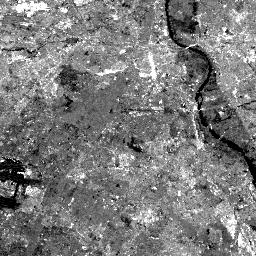

In [5]:
import logging, sys, json
from pathlib import Path
sys.path.insert(0, "/Users/dhruvpandey/Desktop/satquery")

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s")

from backend.orchestrator.graph import invoke_satquery
from backend.orchestrator.state import empty_state
from backend.rendering.raster_preview import render_geotiff_preview
from IPython.display import Image, display


def show_tool_results(result, label):
    print(f"\n{'#' * 90}\nFULL TOOL CALL / RESPONSE PAYLOAD -- {label}\n{'#' * 90}")
    for i, entry in enumerate(result.get("tool_results") or [], start=1):
        print(f"\n--- Step {i}: {entry['tool']}  (status={entry['result'].get('status')}, {entry.get('duration_ms', 0):.0f}ms) ---")
        print(json.dumps(entry["result"], indent=2, default=str))


sar_path = str((Path("/Users/dhruvpandey/Desktop/satquery/Tool_3_fetch_sar_imagery/test_runs/sample_sar_output.tif")).resolve())

print("### Modality A: vision-language interpretation of a SAR (radar) raster ###\n")
state_a = empty_state(
    query="Describe what this radar image shows.",
    input_file=sar_path,
)
result_a = invoke_satquery(state_a)
print("\nMODALITY A ANSWER:\n", result_a["final_answer"])
show_tool_results(result_a, "Modality A (vision)")

print("\n\n### Modality B: independently retrieved meteorological data for the same AOI ###\n")
state_b = empty_state(
    query="Get weather and rainfall context for this location.",
    latitude=28.61,
    longitude=77.21,
    start_date="2025-01-01",
    end_date="2025-01-31",
)
result_b = invoke_satquery(state_b)
print("\nMODALITY B ANSWER:\n", result_b["final_answer"])
show_tool_results(result_b, "Modality B (weather)")

print("\n\n" + "=" * 80)
print("STATUS A:", result_a["status"], " STATUS B:", result_b["status"])

print("\nInput (SAR raster interpreted by modality A):")
display(Image(render_geotiff_preview(sar_path, size=400)))

---
## Example 4 — Temporal change detection

Given two already-aligned rasters (T1/T2 NDVI, in this case), the query
classifies as a `chain_temporal` intent *before* any single-tool keyword
matching — so it isn't routed to a plain "describe" or "inspect" call.
The orchestrator's fixed agenda for this intent is: **Tool 6** (pre-flight
grid-alignment QA — refuses to diff two rasters that aren't co-registered)
then **Tool 7** (the actual differencing + classified change mask). The cell
output shows Tool 6's extracted metadata (confirming the grid alignment) and
Tool 7's complete statistical payload (per-class areas, delta percentiles,
histogram), in addition to the generated difference/mask file paths.

2026-09-08 23:20:00,337  INFO      satquery.pipeline  [REQUEST RECEIVED] query='Detect vegetation change between these two dates and summarize the loss and gain.'
2026-09-08 23:20:00,338  INFO      satquery.pipeline  [VALIDATION OK]
2026-09-08 23:20:00,338  INFO      satquery.pipeline  [ORCHESTRATOR INITIATED] provider=anthropic model=claude-sonnet-5
2026-09-08 23:20:00,339  INFO      satquery.pipeline  [ORCHESTRATOR TOOL CALL] tool=inspect_geotiff_metadata reason='Pre-flight grid alignment'
2026-09-08 23:20:00,339  INFO      satquery.pipeline  [TOOL CALL] inspect_geotiff_metadata args={'file_path': '/Users/dhruvpandey/Desktop/satquery/Tool_7_analyze_temporal_change/test_runs/sample_indices_t2.tif', 'compare_with': '/Users/dhruvpandey/Desktop/satquery/Tool_7_analyze_temporal_change/test_runs/sample_indices_t1.tif', 'calculate_statistics': True, 'calculate_histogram': True}
2026-09-08 23:20:00,404  INFO      satquery.pipeline  [TOOL OUTPUT] inspect_geotiff_metadata status=success durati


STATUS: success
TOOL CHAIN: ['inspect_geotiff_metadata -> success', 'analyze_temporal_change -> success']

FINAL ANSWER:
 Based on the NDVI comparison between the two dates, vegetation declined significantly across about 42.3 km² (roughly 9.76% of the area), while gains were seen over 23.8 km² (about 5.49%). The majority of the area — nearly 85% (367.5 km²) — remained stable with no meaningful change. Overall, losses outweighed gains, resulting in a net vegetation decrease of about 18.5 km² across the region.

METADATA EXTRACTED (Tool 6 pre-flight QA -- confirms T1/T2 are grid-aligned before diffing):
{
  "spatial": {
    "crs": "EPSG:4326",
    "is_geographic": true,
    "is_projected": false,
    "coordinate_units": "degrees",
    "resolution": {
      "x": 0.0007812500000000111,
      "y": 0.0007812499999999972,
      "unit": "degrees"
    },
    "bounds_native": {
      "left": 77.1,
      "bottom": 28.5,
      "right": 77.3,
      "top": 28.7
    },
    "bounds_wgs84": {
      "m

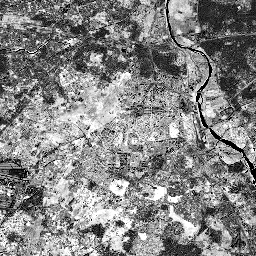


T2 (after):


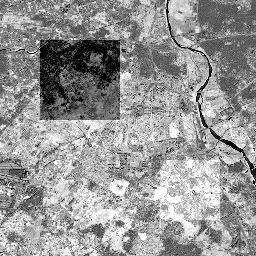


Generated change mask (loss / stable / gain):


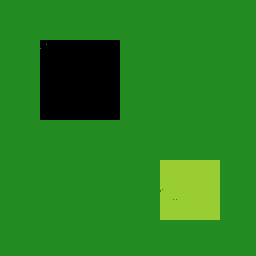

In [6]:
import logging, sys, json
from pathlib import Path
sys.path.insert(0, "/Users/dhruvpandey/Desktop/satquery")

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s")

from backend.orchestrator.graph import invoke_satquery
from backend.orchestrator.state import empty_state
from backend.rendering.raster_preview import render_geotiff_preview
from IPython.display import Image, display


def show_tool_results(result):
    print("\n" + "#" * 90)
    print("FULL TOOL CALL / RESPONSE PAYLOADS")
    print("#" * 90)
    for i, entry in enumerate(result.get("tool_results") or [], start=1):
        print(f"\n--- Step {i}: {entry['tool']}  (status={entry['result'].get('status')}, {entry.get('duration_ms', 0):.0f}ms) ---")
        print(json.dumps(entry["result"], indent=2, default=str))


root = Path("/Users/dhruvpandey/Desktop/satquery/Tool_7_analyze_temporal_change/test_runs")
t1 = str((root / "sample_indices_t1.tif").resolve())
t2 = str((root / "sample_indices_t2.tif").resolve())

state = empty_state(
    query="Detect vegetation change between these two dates and summarize the loss and gain.",
    raster_before_path=t1,
    raster_after_path=t2,
)
result = invoke_satquery(state)

print("\n" + "=" * 80)
print("STATUS:", result["status"])
print("TOOL CHAIN:", [f"{r['tool']} -> {r['result'].get('status')}" for r in result["tool_results"]])
print("\nFINAL ANSWER:\n", result["final_answer"])

qa_result = result["tool_results"][0]["result"]
print("\nMETADATA EXTRACTED (Tool 6 pre-flight QA -- confirms T1/T2 are grid-aligned before diffing):")
print(json.dumps({"spatial": qa_result.get("spatial"), "compatibility": qa_result.get("compatibility")}, indent=2))

show_tool_results(result)

change_mask_path = result["tool_results"][1]["result"]["generated_products"]["change_mask_path"]
print("\nT1 (before):")
display(Image(render_geotiff_preview(t1, size=350, band_selection=[1])))
print("\nT2 (after):")
display(Image(render_geotiff_preview(t2, size=350, band_selection=[1])))
print("\nGenerated change mask (loss / stable / gain):")
display(Image(render_geotiff_preview(change_mask_path, size=350)))

---
## Example 5 — Autonomous multi-tool mission: wildfire burn severity

The deepest form of autonomy in this system: a **named mission**. "wildfire"
is classified as intent *before* any keyword/LLM tool selection happens at
all, and the orchestrator builds the mission's entire agenda up front rather
than deciding step by step. From the graph's point of view this is a single
tool call (`workflow_wildfire_burn_severity`) — but that one call internally
chains **Tool 5 → Tool 6 → Tool 7 → Tool 8** inside `satquery_workflows.py`,
each with its own row in the mission's own `audit_trail`. The cell output
includes the mission's complete raw JSON (executive summary, burn severity
breakdown, zonal LULC/terrain cross-tabulation, and the generated artifact
paths) in full, not summarized.

**Caveat, stated plainly (never fabricate a result):** no real pre/post
wildfire pair is bundled with this repo, so this example reuses the same
multispectral sample as both "pre" and "post" purely to demonstrate the
pipeline mechanics — diffing a raster against itself correctly finds **zero**
burned area. Swap in a genuine pre-fire/post-fire pair for a real assessment.

2026-09-08 23:20:03,473  INFO      satquery.pipeline  [REQUEST RECEIVED] query='Map wildfire burn severity and fire scar for this area.'
2026-09-08 23:20:03,473  INFO      satquery.pipeline  [VALIDATION OK]
2026-09-08 23:20:03,474  INFO      satquery.pipeline  [ORCHESTRATOR INITIATED] provider=anthropic model=claude-sonnet-5
2026-09-08 23:20:03,474  INFO      satquery.pipeline  [ORCHESTRATOR TOOL CALL] tool=workflow_wildfire_burn_severity reason='Run workflow_wildfire_burn_severity'
2026-09-08 23:20:03,475  INFO      satquery.pipeline  [TOOL CALL] workflow_wildfire_burn_severity args={'pre_raster_path': '/Users/dhruvpandey/Desktop/satquery/Tool_2_fetch_multispectral_imagery/test_runs/sample_multispectral_output.tif', 'post_raster_path': '/Users/dhruvpandey/Desktop/satquery/Tool_2_fetch_multispectral_imagery/test_runs/sample_multispectral_output.tif', 'lulc_raster_path': '/Users/dhruvpandey/Desktop/satquery/Tool_8_analyze_spatial_landcover_terrain/test_runs/sample_worldcover_10m.tif', '


STATUS: success
TOOL CHAIN: ['workflow_wildfire_burn_severity -> success']

FINAL ANSWER:
 The analysis found no evidence of wildfire burn scars in this area — 100% of the 433.6 km² assessed area shows stable vegetation with no significant burn severity (no high, moderate, or low severity burn classes detected). The land cover here is dominated by cropland (about 61.6%) and tree cover (about 20%), with gentle terrain (average slope around 1 degree). In short, there is no active or historical fire damage indicated by this dataset for the area analyzed.

GENERATED ARTIFACTS:
{
  "pre_nbr_raster": "/private/tmp/claude-501/-Users-dhruvpandey-Desktop-satquery/ed346266-5bfe-4fb4-99a1-1d1ad9345e0b/scratchpad/nb_examples/wildfire_output/sample_multispectral_output_indices_20260908T175003Z.tif",
  "post_nbr_raster": "/private/tmp/claude-501/-Users-dhruvpandey-Desktop-satquery/ed346266-5bfe-4fb4-99a1-1d1ad9345e0b/scratchpad/nb_examples/wildfire_output/sample_multispectral_output_indices_2026090

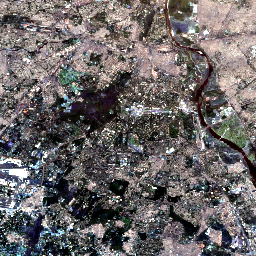

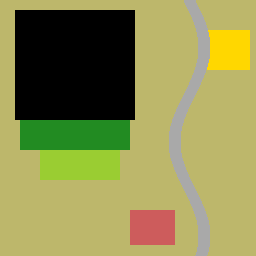

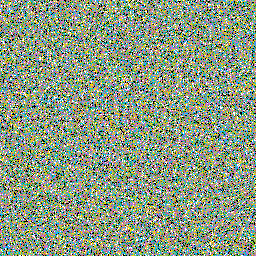


Generated NBR difference and burn-severity mask (both blank -- correctly zero change, see caveat above):


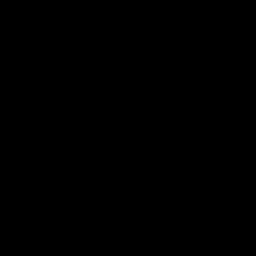

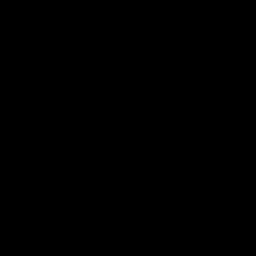

In [7]:
import logging, sys, json
from pathlib import Path
sys.path.insert(0, "/Users/dhruvpandey/Desktop/satquery")

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s")

from backend.orchestrator.graph import invoke_satquery
from backend.orchestrator.state import empty_state
from backend.rendering.raster_preview import render_geotiff_preview
from IPython.display import Image, display


def show_tool_results(result):
    print("\n" + "#" * 90)
    print("FULL TOOL CALL / RESPONSE PAYLOAD")
    print("#" * 90)
    for i, entry in enumerate(result.get("tool_results") or [], start=1):
        print(f"\n--- Step {i}: {entry['tool']}  (status={entry['result'].get('status')}, {entry.get('duration_ms', 0):.0f}ms) ---")
        print(json.dumps(entry["result"], indent=2, default=str))


ROOT = Path("/Users/dhruvpandey/Desktop/satquery")
# Using the same bundled multispectral sample as both "pre" and "post" purely
# to demonstrate the pipeline mechanics without a real burn event on hand —
# expect ~zero detected change since it's diffed against itself. Swap in a
# real pre/post pair for a genuine assessment.
multispectral = str((ROOT / "Tool_2_fetch_multispectral_imagery/test_runs/sample_multispectral_output.tif").resolve())
lulc = str((ROOT / "Tool_8_analyze_spatial_landcover_terrain/test_runs/sample_worldcover_10m.tif").resolve())
dem = str((ROOT / "Tool_8_analyze_spatial_landcover_terrain/test_runs/sample_copernicus_dem_30m.tif").resolve())
out_dir = "/private/tmp/claude-501/-Users-dhruvpandey-Desktop-satquery/ed346266-5bfe-4fb4-99a1-1d1ad9345e0b/scratchpad/nb_examples/wildfire_output"

state = empty_state(
    query="Map wildfire burn severity and fire scar for this area.",
    raster_before_path=multispectral,
    raster_after_path=multispectral,
    lulc_raster_path=lulc,
    dem_raster_path=dem,
    analysis_output_dir=out_dir,
)
result = invoke_satquery(state)

print("\n" + "=" * 80)
print("STATUS:", result["status"])
print("TOOL CHAIN:", [f"{r['tool']} -> {r['result'].get('status')}" for r in result["tool_results"]])
print("\nFINAL ANSWER:\n", result["final_answer"])

mission_result = result["tool_results"][-1]["result"]
print("\nGENERATED ARTIFACTS:")
print(json.dumps(mission_result.get("generated_artifacts"), indent=2))

show_tool_results(result)

print("\nInputs — multispectral scene (used as both pre and post), LULC, and DEM:")
display(Image(render_geotiff_preview(multispectral, size=300)))
display(Image(render_geotiff_preview(lulc, size=300)))
display(Image(render_geotiff_preview(dem, size=300, band_selection=[1])))

artifacts = mission_result["generated_artifacts"]
print("\nGenerated NBR difference and burn-severity mask (both blank -- correctly zero change, see caveat above):")
display(Image(render_geotiff_preview(artifacts["delta_nbr_difference_raster"], size=300)))
display(Image(render_geotiff_preview(artifacts["burn_severity_mask"], size=300)))

---
## Appendix — Tool 6 standalone: a plain TIFF vs. a GeoTIFF

Tool 6 (`inspect_geotiff_metadata`) is called **directly here, with no
orchestrator and no LLM involved** — proof that the 8 science tools are
genuinely standalone functions, not something that only works wired through
`invoke_satquery`. It's run on two rasters:

1. **A plain `.tif`** — a 256x256 uint8 image written with `crs=None` and an
   identity transform (no real-world georeferencing at all, the same as a
   photo saved in TIFF format).
2. **A GeoTIFF** — the real Sentinel-2 optical raster from Example 1
   (`Tool_1_fetch_optical_imagery/test_runs/sample_optical_output.tif`),
   which carries a CRS (`EPSG:4326`) and an affine transform tying its
   pixels to real longitude/latitude.

Both files are structurally identical TIFFs (same driver, band layout,
dtype) — the only difference is the presence of CRS + transform metadata.
The side-by-side table at the end of the output shows exactly what that
buys you: `bounds_wgs84`, `approx_area_km2`, and `is_valid_for_ml` all
depend entirely on georeferencing being present. Without it, Tool 6 still
extracts full per-band statistics and integrity checks, but flags the file
as **not** ML/analysis-ready (`is_georeferenced=False`, `is_valid_for_ml=False`)
since it can't be located on Earth or measured in real units.


In [8]:
import sys, json
from pathlib import Path

sys.path.insert(0, "/Users/dhruvpandey/Desktop/satquery")

import numpy as np
import rasterio
from rasterio.transform import Affine

from Tool_6_inspect_geotiff_metadata.inspect_geotiff_metadata import (
    GeoTIFFInspectionRequest,
    inspect_geotiff_metadata,
)

# --- 1) Build a plain, non-georeferenced TIFF (no CRS, no real-world transform) ---
plain_tiff_path = Path(
    "/Users/dhruvpandey/Desktop/satquery/Tool_6_inspect_geotiff_metadata/test_runs/plain_photo_no_georef.tif"
)
rng = np.random.default_rng(42)
rgb = rng.integers(0, 255, size=(3, 256, 256), dtype=np.uint8)

with rasterio.open(
    plain_tiff_path,
    "w",
    driver="GTiff",
    height=256,
    width=256,
    count=3,
    dtype="uint8",
    crs=None,
    transform=Affine.identity(),
) as dst:
    dst.write(rgb)

print("Created plain TIFF at:", plain_tiff_path)

# --- 2) A real georeferenced Sentinel-2 GeoTIFF already produced by Tool 1 ---
geotiff_path = Path(
    "/Users/dhruvpandey/Desktop/satquery/Tool_1_fetch_optical_imagery/test_runs/sample_optical_output.tif"
)

# --- Run Tool 6 directly (no orchestrator, no LLM) on each ---
plain_result = inspect_geotiff_metadata(GeoTIFFInspectionRequest(file_path=str(plain_tiff_path)))
geo_result = inspect_geotiff_metadata(GeoTIFFInspectionRequest(file_path=str(geotiff_path)))

print("\n" + "#" * 90)
print("1) PLAIN TIFF (no CRS, no georeferencing) — full extracted output")
print("#" * 90)
print(json.dumps(plain_result, indent=2, default=str))

print("\n" + "#" * 90)
print("2) GEOTIFF (Sentinel-2, EPSG:4326) — full extracted output")
print("#" * 90)
print(json.dumps(geo_result, indent=2, default=str))

# --- Side-by-side comparison of the fields that actually differ ---
def pick(res, *keys):
    cur = res
    for k in keys:
        cur = cur.get(k) if isinstance(cur, dict) else None
    return cur

rows = [
    ("driver", ("file", "driver")),
    ("crs", ("spatial", "crs")),
    ("is_geographic", ("spatial", "is_geographic")),
    ("bounds_wgs84", ("spatial", "bounds_wgs84")),
    ("approx_area_km2", ("spatial", "approx_area_km2")),
    ("is_georeferenced", ("quality", "is_georeferenced")),
    ("is_valid_for_ml", ("quality", "is_valid_for_ml")),
]

print("\n" + "#" * 90)
print("SIDE-BY-SIDE: what a missing CRS/transform actually changes")
print("#" * 90)
print(f"{'field':<20}{'plain .tif':<35}{'.tif (georeferenced)'}")
print("-" * 90)
for label, path in rows:
    print(f"{label:<20}{str(pick(plain_result, *path)):<35}{str(pick(geo_result, *path))}")


Created plain TIFF at: /Users/dhruvpandey/Desktop/satquery/Tool_6_inspect_geotiff_metadata/test_runs/plain_photo_no_georef.tif

##########################################################################################
1) PLAIN TIFF (no CRS, no georeferencing) — full extracted output
##########################################################################################
{
  "status": "success",
  "file": {
    "file_name": "plain_photo_no_georef.tif",
    "file_path": "/Users/dhruvpandey/Desktop/satquery/Tool_6_inspect_geotiff_metadata/test_runs/plain_photo_no_georef.tif",
    "file_size_bytes": 197062,
    "driver": "GTiff"
  },
  "spatial": {
    "crs": "UNREFERENCED",
    "is_geographic": false,
    "is_projected": false,
    "coordinate_units": "pixels",
    "resolution": {
      "x": 1.0,
      "y": 1.0,
      "unit": "pixels"
    },
    "bounds_native": {
      "left": 0.0,
      "bottom": 256.0,
      "right": 256.0,
      "top": 0.0
    },
    "bounds_wgs84": null,
    "appr

/Users/dhruvpandey/Desktop/satquery/.venv/lib/python3.13/site-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


---
## Playground

Moved to its own notebook, **[playground.ipynb](./playground.ipynb)**, so you can experiment with your own queries and files without re-running this whole walkthrough every time. It has two sections: a free-text query cell (drives the full orchestrator, same as the examples above) and a direct two-GeoTIFF comparison cell (Tool 6 -> Tool 7, no orchestrator/LLM involved) -- the latter defaults to two real Sentinel-1 SAR scenes over Nepal's Trishuli River valley, before and after the 26 August 2026 Langtang Lirung glacier collapse and flood (see `nepal_flood_case/`).


---
## Summary

| # | Use case | Intent path | Tools involved |
|---|---|---|---|
| 1 | VQA | `single_tool` (LLM-picked) | `analyze_imagery_vlm` |
| 2 | Grounding | `single_tool` -> derived 2-hop chain | `inspect_geotiff_metadata` -> `fetch_sar_imagery` |
| 3 | Multi-modal VQA | two independent `single_tool` requests | `analyze_imagery_vlm`, `fetch_weather_environment` |
| 4 | Temporal change | `chain_temporal` (fixed agenda) | `inspect_geotiff_metadata` -> `analyze_temporal_change` |
| 5 | Autonomous mission | `mission_wildfire` (fixed agenda) | `workflow_wildfire_burn_severity` (internally: Tools 5, 6, 7, 8) |

Every example above showed, for every tool call made: the exact argument
payload sent (via the live `[TOOL CALL]` log line), the complete raw JSON
response the tool returned (via the `FULL TOOL CALL / RESPONSE PAYLOADS`
block), and a rendered preview of every raster involved — not just a
one-line summary or a final narrative answer.

Further reading: [`README.md`](README.md) (architecture, full tool
encyclopedia, config reference), [`backend/orchestrator/README.md`]
(backend/orchestrator/README.md) (graph/handshake internals), and
`skills/derive-aoi-from-uploaded-file/SKILL.md` for the grounding principle
demonstrated in Example 2.